In [5]:
import pandas as pd
#from google.colab import drive
#drive.mount('/content/drive')

df = pd.read_csv('/content/sample_data/cgpa_package_placement.csv')
df.head()
print(df.info())
print(df.describe)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None
<bound method NDFrame.describe of      cgpa  package
0    6.89     3.26
1    5.12     1.98
2    7.82     3.25
3    7.42     3.67
4    6.94     3.57
..    ...      ...
195  6.93     2.46
196  5.89     2.57
197  7.21     3.24
198  7.63     3.96
199  6.22     2.33

[200 rows x 2 columns]>


In [6]:
X = df['cgpa']           # ← DataFrame (n_rows, 1) // we need (100,1) format in shape, its the requirement of sklearn
y = df['package']          # Series

In [7]:
X.shape

(200,)

In [8]:
y.shape

(200,)

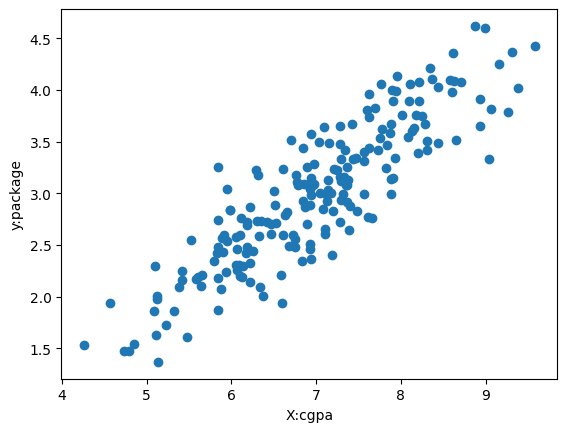

In [9]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.xlabel('X:cgpa')
plt.ylabel('y:package')
plt.show()


In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [11]:
X_train

,cgpa
156,7.38
175,7.04
12,8.94
137,7.14
53,6.47
...,...
70,5.79
30,7.36
89,6.42
99,6.61


In [12]:
X_test

,cgpa
50,9.58
15,7.25
91,6.22
96,7.11
95,6.63
162,5.53
174,7.32
140,7.91
7,6.75
43,7.66


In [13]:
X_train.shape

(160,)

In [14]:
X_test.shape

(40,)

In [15]:

def fit():
  x_sum = 0
  x_mean = 0
  y_sum = 0
  y_mean = 0
  m_numerator = 0
  m_denominator = 0
  #
  # b = (y_bar - m*x_bar)
  # m = summ.(x-x_bar)(y-y_bar)/summ.(x-x_bar)^2
  for i in range(len(X_train)):
    x_sum += X[i];
    x_mean = x_sum/len(X_train)
    y_sum += y[i];
    y_mean = y_sum/len(y_train)


 # print(x_mean,y_mean)
 # print(X.mean(),y.mean())

  for i in range(len(X_train)):
    m_numerator += (X[i]-x_mean)*(y[i]-y_mean)
    m_denominator += (X[i]-x_mean)**2

  m = m_numerator/m_denominator
  b = y_mean - m*x_mean
 # print(m,b)
  return m,b



In [16]:
def predict(m,b,X_test):
  y_pred = []
  for i in range(len(X_test)):
    y_pred.append(m*X_test[i]+b)
  return y_pred




In [17]:

m,b = fit()
#print(m,b)
y_pred = predict(m,b,X_test.values.reshape(-1))
#X_test.values.reshape(-1)
pd.DataFrame({'cgpa':X_test.values.reshape(-1), 'Actual_Package':y_test.values.reshape(-1),'Predicted_package':y_pred})
new_ypred = predict(m,b,[9.38])
print(new_ypred)

[np.float64(4.3711158599784)]


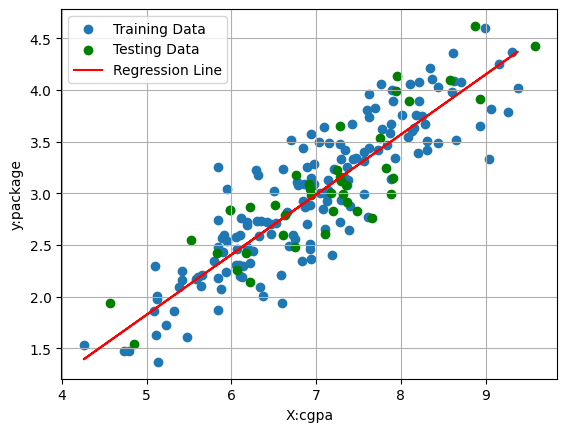

In [18]:
import matplotlib.pyplot as plt
plt.scatter(X_train,y_train)
plt.scatter(X_test,y_test,color="green")
plt.plot(X_train,m*X_train+b,color='red')
plt.legend(['Training Data','Testing Data','Regression Line'])
plt.xlabel('X:cgpa')
plt.ylabel('y:package')
plt.grid()
plt.show()

Loss Function :
 MAE (Mean absolute error)


In [33]:
#Loss Function
#MAE
e_absolute = 0
for i in range(len(y_test)) :
  e_absolute +=  abs(y_test.values[i] - y_pred[i])

mean_absolute = e_absolute/len(y_test)

mean_absolute

np.float64(0.26146614396723517)

MSE : Mean Square Error


In [35]:
e_square = 0
for i in range(len(y_test)) :
  e_square += (y_test.values[i] - y_pred[i])**2
mean_square = e_square/len(y_test)
mean_square

np.float64(0.0975035629690533)

RMSE : Root Mean Square Error


In [36]:
root = mean_square**0.5
root

np.float64(0.3122556051843638)

R2 Score


In [43]:
ssr = 0
sst = 0
y_test_mean = 0
for i in range(len(y_test)) :
  y_test_mean += y_test.values[i]
y_test_mean = y_test_mean/len(y_test)

mean = y_test.mean()
print(mean)
print(y_test_mean)

for i in range(len(y_test)) :
  ssr += (y_pred[i] - y_test_mean)**2
  sst += (y_test.values[i] - y_test_mean)**2

R_square = ssr/sst

R_square

3.0555
3.0555000000000008


np.float64(0.8362037750852747)

In [41]:
R_nume = 0
R_denom = 0

for i in range(len(y_test)) :
  R_nume += (y_pred[i] - y_test.values[i])**2
  R_denom += (y_test.values[i] - y_test_mean)**2

R_square_New = 1 - R_nume/R_denom
R_square_New

np.float64(0.7680942312419091)